# Training Pipeline — Home Credit Default Risk

LightGBM training pipeline for predicting loan default probability (binary classification: `TARGET=1` = default) on the [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) dataset.

---

## Pipeline Overview

| Component | Description |
|-----------|-------------|
| **Input data** | Feature matrix from `build_all_features()` — combines application, bureau, previous applications, etc. |
| **Train/test split** | Stratified 80/20 → 80% for KFold training, 20% holdout for final evaluation |
| **Cross-validation** | `StratifiedKFold` with 5 folds on the training set |
| **Mean encoding** | Computed **per fold** (using only train-fold statistics) to prevent leakage |
| **Class imbalance** | `BaggingClassifier` down-samples majority class across 3 sub-folds, trains 3 estimators and averages predictions |
| **Metric** | ROC-AUC (OOF on train + holdout test) |

---

## Differences from Kaggle kernel reference

- **Original kernel:** trains on 100% of labelled data, predicts on the unlabelled test set → Kaggle submission
- **This pipeline:** holds out 20% for offline evaluation (internal use, no submission)

## Features excluded from model input

| Feature | Reason |
|---------|--------|
| `SK_ID_CURR` | Row identifier — no predictive value |
| `TARGET` | Target variable |
| `prev_sum_CODE_REJECT_REASON_CLIENT` | High-noise engineered feature |
| `bureau_sum_CREDIT_ACTIVE_Active` | High-noise engineered feature |


## 1. Imports & Logging Setup

In [ ]:
from __future__ import annotations

import argparse
import gc
import json
import logging
import pickle
import sys
import time
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split

# ── Suppress warnings ────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")                        # Python warnings
logging.getLogger("lightgbm").setLevel(logging.ERROR)   # LightGBM log spam

# Add project root to path
sys.path.insert(0, str(Path(".").resolve().parent))
from training.feature_engineering import build_all_features, mean_encode

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

## 2. Configuration — Excluded Features & LightGBM Parameters

- `EXCLUDED_FEATS_SUFFIXES`: suffix list of features dropped from model input (see overview above for rationale)
- `LGB_PARAMS`: LightGBM hyperparameters tuned for this imbalanced-class problem (~8% default rate)


In [ ]:
# ─── Features excluded from training (not predictors) ─────────────────────────

EXCLUDED_FEATS_SUFFIXES = [
    "prev_sum_CODE_REJECT_REASON_CLIENT",
    "bureau_sum_CREDIT_ACTIVE_Active",
]


# ─── LightGBM params (identical to lgb1.ipynb cell 23) ──────────────────────

LGB_PARAMS = dict(
    n_estimators        = 5000,
    learning_rate       = 0.03,
    num_leaves          = 26,
    metric              = "auc",
    colsample_bytree    = 0.3,
    subsample           = 0.9320,
    max_depth           = 4,
    reg_alpha           = 4.8299,
    reg_lambda          = 3.6335,
    min_split_gain      = 0.0068,
    min_child_weight    = 9.8138,
    silent              = True,
    verbose             = -1,
    n_jobs              = -1,
    class_weight        = {0: 1, 1: 1.0122},
)

## 3. BaggingClassifier — Down-sampling for Class Imbalance

Because the default rate (`TARGET=1`) is only ~8%, training directly on the full dataset biases the model toward the majority class.

`BaggingClassifier` addresses this by:

1. Keeping the **entire minority class** (`TARGET=1`) intact
2. Splitting the **majority class** (`TARGET=0`) into `n_estimators` equal parts via KFold
3. Training `n_estimators` independent LightGBM models — each sees minority + one part of majority
4. **Prediction = average** of probabilities across all estimators

Each estimator trains on a more balanced class ratio (~1:1 to 1:3), reducing majority-class bias without discarding any majority data.


In [ ]:
class BaggingClassifier:
    """
    Down-sampling bagging that mimics lgb1.ipynb.

    For each outer fold:
        minority (TARGET==1) is kept whole.
        majority (TARGET==0) is split into n_estimators sub-folds;
        we train once per sub-fold on minority + 1/n_estimators of majority.
    Predictions are averaged across the n_estimators.
    """

    def __init__(self, base_params: dict, n_estimators: int = 3):
        self.base_params_    = base_params
        self.n_estimators_   = n_estimators
        self.estimators_     = []
        self.feature_importances_gain_  = None
        self.feature_importances_split_ = None
        self.n_classes_ = 2

    def fit(self, X: pd.DataFrame, y: pd.Series,
            eval_set=None, eval_metric="auc",
            verbose=200, early_stopping_rounds=100,
            categorical_feature=None):
        self.estimators_ = []
        n_feats = X.shape[1]
        self.feature_importances_gain_  = np.zeros(n_feats)
        self.feature_importances_split_ = np.zeros(n_feats)

        if self.n_estimators_ == 1:
            logger.info("n_estimators=1, no downsampling")
            estimator = LGBMClassifier(**self.base_params_)
            fit_kwargs = dict(
                eval_set=[(X, y)] + (eval_set or []),
                eval_metric=eval_metric,
                callbacks=[
                    early_stopping(early_stopping_rounds, verbose=False),
                    log_evaluation(verbose),
                ],
            )
            if categorical_feature:
                fit_kwargs["categorical_feature"] = categorical_feature
            estimator.fit(X, y, **fit_kwargs)
            self.estimators_.append(estimator)
            self.feature_importances_gain_  += estimator.booster_.feature_importance(importance_type="gain")
            self.feature_importances_split_ += estimator.booster_.feature_importance(importance_type="split")
            return

        # --- downsampling ---
        minority_cls = y.value_counts().sort_values().index[0]
        majority_cls = y.value_counts().sort_values().index[1]
        logger.info(f"majority class: {majority_cls}  minority class: {minority_cls}")

        X_min = X.loc[y == minority_cls]
        y_min = y.loc[y == minority_cls]
        X_maj = X.loc[y == majority_cls]
        y_maj = y.loc[y == majority_cls]

        kf = KFold(n_splits=self.n_estimators_, shuffle=True, random_state=42)
        for _rest, this in kf.split(y_maj):
            logger.info("  training on a subset")
            X_sub = pd.concat([X_min, X_maj.iloc[this]])
            y_sub = pd.concat([y_min, y_maj.iloc[this]])

            estimator = LGBMClassifier(**deepcopy(self.base_params_))
            fit_kwargs = dict(
                eval_set=[(X_sub, y_sub)] + (eval_set or []),
                eval_metric=eval_metric,
                callbacks=[
                    early_stopping(early_stopping_rounds, verbose=False),
                    log_evaluation(verbose),
                ],
            )
            if categorical_feature:
                fit_kwargs["categorical_feature"] = categorical_feature
            estimator.fit(X_sub, y_sub, **fit_kwargs)
            self.estimators_.append(estimator)
            self.feature_importances_gain_  += estimator.booster_.feature_importance(importance_type="gain") / self.n_estimators_
            self.feature_importances_split_ += estimator.booster_.feature_importance(importance_type="split") / self.n_estimators_

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        n_samples = X.shape[0]
        proba = np.zeros((n_samples, self.n_classes_))
        for estimator in self.estimators_:
            proba += estimator.predict_proba(
                X, num_iteration=estimator.best_iteration_
            ) / len(self.estimators_)
        return proba

## 4. Outer KFold Training Loop — `train_with_kfold()`

Runs a `StratifiedKFold` (5 folds) on the training set:

1. **Fold split**: `StratifiedKFold` ensures consistent `TARGET` ratio across folds
2. **Mean encoding**: computed on **train fold only** — val fold only receives the encoded values, never contributes to statistics → no leakage
3. **Object column encoding**: remaining string-typed categorical columns are factorized
4. **Training**: `BaggingClassifier` with 3 sub-estimators per fold; `random_state = n_fold × 619`
5. **OOF predictions**: predictions on each val fold are stored to compute overall AUC

In [ ]:
def train_with_kfold(
    data: pd.DataFrame,          # full feature matrix INCLUDING TARGET
    y:    pd.Series,
    meanenc_feats: list[str],
    cat_feats:     list[str],
    n_splits: int    = 5,
    n_bag:    int    = 3,
) -> tuple[list[BaggingClassifier], np.ndarray, list[str]]:
    """
    5-fold outer loop matching lgb1.ipynb cell 23 exactly:
      - mean_encode applied per fold (train+val+test combined as val_test)
      - BaggingClassifier with 3 sub-estimators per fold
      - random_state = n_fold * 619  (per reference)

    Returns:
        (list_of_classifiers, oof_preds_on_train, feature_names)
    """
    # Features to exclude from model input
    excluded_feats = ["SK_ID_CURR", "TARGET"] + EXCLUDED_FEATS_SUFFIXES
    # make sure we only exclude cols that actually exist
    excluded_feats = [f for f in excluded_feats if f in data.columns]

    oof_preds = np.zeros(data.shape[0])
    classifiers = []
    scores = []

    folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=90210)

    for n_fold, (trn_idx, val_idx) in enumerate(folds.split(data, data["TARGET"])):
        trn = data.iloc[trn_idx]
        val = data.iloc[val_idx]

        logger.info(f"\nFold {n_fold + 1}/{n_splits}  doing mean_encoding...")
        trn_enc, val_enc = mean_encode(trn, val, meanenc_feats, "TARGET", drop=True)

        # Feature list (same for both trn and val after mean_encode)
        features = [f for f in trn_enc.columns if f not in excluded_feats]

        trn_x = trn_enc[features].copy()
        val_x = val_enc[features].copy()
        trn_y = trn_enc["TARGET"]
        val_y = val_enc["TARGET"]

        # Encode any remaining object columns (e.g. _mode aggregations from aux tables)
        for col in trn_x.select_dtypes(include="object").columns:
            trn_x[col], indexer = pd.factorize(trn_x[col])
            val_x[col] = indexer.get_indexer(val_x[col])

        params = deepcopy(LGB_PARAMS)
        params["random_state"] = n_fold * 619

        # Only keep cat_feats that still exist in features after mean_encode drop
        # and ensure they are numeric dtype (LightGBM requirement)
        features_set = set(features)
        active_cat_feats = [f for f in cat_feats if f in features_set
                            and trn_x[f].dtype != object]

        clf = BaggingClassifier(base_params=params, n_estimators=n_bag)
        clf.fit(
            trn_x, trn_y,
            eval_set=[(val_x, val_y)],
            eval_metric="auc",
            verbose=200,
            early_stopping_rounds=100,
            categorical_feature=active_cat_feats if active_cat_feats else "auto",
        )
        classifiers.append(clf)

        oof_preds[val_idx] = clf.predict_proba(val_x)[:, 1]
        fold_score = roc_auc_score(val_y, oof_preds[val_idx])
        scores.append(fold_score)
        logger.info(f"Fold {n_fold + 1} AUC: {fold_score:.6f}")

        del trn, val, trn_enc, val_enc, trn_x, val_x
        gc.collect()

    oof_auc = roc_auc_score(y, oof_preds)
    logger.info(f"\nFull AUC score {oof_auc:.6f} +- {np.std(scores):.4f}")

    # Feature names = features from last fold (stable across folds)
    excluded_feats_set = set(excluded_feats)
    # Recompute for return
    feature_names = features

    return classifiers, oof_preds, feature_names

## 5. Training Execution

Orchestrates the full pipeline in 4 steps:

| Step | Description |
|------|-------------|
| **1. Feature engineering** | Calls `build_all_features(data_dir)` to produce the full feature matrix |
| **2. Stratified split** | 80/20 split with `stratify=y` — preserves default rate in both sets |
| **3. KFold training** | Calls `train_with_kfold()` → returns classifiers, OOF predictions, feature names |
| **4. Test evaluation** | Mean-encodes test set using full train as reference, then averages predictions across all fold classifiers |

**Saved artifacts** (written to `output_dir`):

| File | Contents |
|------|----------|
| `lgbm_ref_v1.pkl` | All classifiers + metadata (feature names, encoding config) |
| `oof_predictions.csv` | OOF predictions on the training set |
| `test_predictions.csv` | Predictions on the holdout test set |
| `feature_names.json` | Ordered list of features used by the model |
| `feature_importance.csv` | Gain + split importance, averaged across all folds |

## 5.1 - Configuration

Set `DATA_DIR` and `OUTPUT_DIR` to match your local environment, then run this cell.


In [ ]:
# ── Paths & hyperparameters — edit here ───────────────────────────────────────
DATA_DIR   = Path("../home-credit-default-risk/")
OUTPUT_DIR = Path("../models/")

TEST_SIZE    = 0.20
N_SPLITS     = 5
N_BAG        = 3
RANDOM_STATE = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"DATA_DIR   = {DATA_DIR}")
logger.info(f"OUTPUT_DIR = {OUTPUT_DIR}")

04:04:33 | INFO | DATA_DIR   = ..\home-credit-default-risk
04:04:33 | INFO | OUTPUT_DIR = ..\models


### 5.2 — Feature Engineering

Builds the full feature matrix by joining all Home Credit tables.
Outputs: `X` (features), `y` (target), `meanenc_feats`, `cat_feats`.


In [ ]:
X, y, meanenc_feats, cat_feats = build_all_features(DATA_DIR)
logger.info(f"Feature matrix: {X.shape} | default rate: {y.mean():.1%}")
logger.info(f"meanenc_feats: {len(meanenc_feats)}  cat_feats: {len(cat_feats)}")

04:04:33 | INFO | Loading application_train...
04:04:38 | INFO |   application: (307511, 117), meanenc_feats=9
04:04:38 | INFO | Loading bureau_balance...
04:04:59 | INFO | Loading bureau...
04:05:27 | INFO |   bureau: (305811, 122)
04:05:27 | INFO | Loading credit_card_balance...
04:06:26 | INFO |   credit_card: (103558, 216)
04:06:27 | INFO | Loading POS_CASH_balance...
04:06:43 | INFO |   pos_cash: (337252, 27)
04:06:43 | INFO | Loading installments_payments...
04:07:22 | INFO |   installments: (339587, 27)
04:07:22 | INFO | Loading previous_application...
04:07:58 | INFO |   prev_app: (338857, 230)
04:07:58 | INFO | Merging all tables...
04:07:59 | INFO |   after merging bureau: (307511, 238)
04:08:00 | INFO |   after merging credit_card: (307511, 454)
04:08:01 | INFO |   after merging pos_cash: (307511, 481)
04:08:02 | INFO |   after merging installments: (307511, 508)
04:08:03 | INFO |   after merging prev_app: (307511, 738)
04:08:03 | INFO |   after cross-table ratios: (307511, 

### 5.3 — Stratified Train / Test Split

Splits 80 % for cross-validated training and holds out 20 % for final evaluation.
`stratify=y` ensures the default rate is preserved in both sets.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
logger.info(f"Train: {X_train.shape}  ({y_train.mean():.1%} default)")
logger.info(f"Test:  {X_test.shape}   ({y_test.mean():.1%} default)")

train_data = X_train.copy()
train_data["TARGET"] = y_train.values
test_x = X_test.copy()

del X, X_train
gc.collect()

04:08:10 | INFO | Train: (246008, 755)  (8.1% default)
04:08:10 | INFO | Test:  (61503, 755)   (8.1% default)


0

### 5.4 — StratifiedKFold Training

Runs 5-fold cross-validation with per-fold mean encoding and bagging.
Produces OOF predictions and one `BaggingClassifier` per fold.


In [ ]:
classifiers, oof_preds, feature_names = train_with_kfold(
    train_data, y_train,
    meanenc_feats=meanenc_feats,
    cat_feats=cat_feats,
    n_splits=N_SPLITS,
    n_bag=N_BAG,
)

04:08:12 | INFO | 
Fold 1/5  doing mean_encoding...
04:08:22 | INFO | majority class: 0  minority class: 1
04:08:22 | INFO |   training on a subset


[200]	training's auc: 0.79874	valid_1's auc: 0.780165
[400]	training's auc: 0.816309	valid_1's auc: 0.78755
[600]	training's auc: 0.828282	valid_1's auc: 0.790616
[800]	training's auc: 0.83773	valid_1's auc: 0.792243
[1000]	training's auc: 0.84592	valid_1's auc: 0.793117
[1200]	training's auc: 0.853734	valid_1's auc: 0.793467
[1400]	training's auc: 0.861262	valid_1's auc: 0.79414
[1600]	training's auc: 0.868264	valid_1's auc: 0.794463
[1800]	training's auc: 0.874684	valid_1's auc: 0.794633


04:08:58 | INFO |   training on a subset


[200]	training's auc: 0.796362	valid_1's auc: 0.779741
[400]	training's auc: 0.814629	valid_1's auc: 0.787292
[600]	training's auc: 0.826045	valid_1's auc: 0.790258
[800]	training's auc: 0.835529	valid_1's auc: 0.79207
[1000]	training's auc: 0.844005	valid_1's auc: 0.793084
[1200]	training's auc: 0.851682	valid_1's auc: 0.793853
[1400]	training's auc: 0.858849	valid_1's auc: 0.79402
[1600]	training's auc: 0.865778	valid_1's auc: 0.794343


04:09:32 | INFO |   training on a subset


...

04:30:44 | INFO |   training on a subset


[200]	training's auc: 0.796833	valid_1's auc: 0.780645
[400]	training's auc: 0.814496	valid_1's auc: 0.788736
[600]	training's auc: 0.826132	valid_1's auc: 0.792241
[800]	training's auc: 0.83578	valid_1's auc: 0.794393
[1000]	training's auc: 0.84451	valid_1's auc: 0.795557
[1200]	training's auc: 0.852403	valid_1's auc: 0.79624
[1400]	training's auc: 0.859557	valid_1's auc: 0.796482


04:31:25 | INFO |   training on a subset


[200]	training's auc: 0.796946	valid_1's auc: 0.780515
[400]	training's auc: 0.81506	valid_1's auc: 0.788765
[600]	training's auc: 0.826853	valid_1's auc: 0.792656
[800]	training's auc: 0.836455	valid_1's auc: 0.795014
[1000]	training's auc: 0.845083	valid_1's auc: 0.796088
[1200]	training's auc: 0.852915	valid_1's auc: 0.796993
[1400]	training's auc: 0.859791	valid_1's auc: 0.797413


04:32:21 | INFO | Fold 5 AUC: 0.799485
04:32:22 | INFO | 
Full AUC score 0.797466 +- 0.0025


### 5.5 — Holdout Test Evaluation

Mean-encodes the test set using each fold's train portion (consistent with training),
then averages predictions from all fold classifiers.


In [ ]:
excluded_feats_set = set(["SK_ID_CURR", "TARGET"] + EXCLUDED_FEATS_SUFFIXES)
test_preds = np.zeros(len(test_x))

test_x_with_dummy = test_x.copy()
test_x_with_dummy["TARGET"] = 0

folds_eval = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=90210)
for fold_idx, (trn_idx, _) in enumerate(folds_eval.split(train_data, train_data["TARGET"])):
    trn_fold = train_data.iloc[trn_idx]
    _, test_enc = mean_encode(trn_fold, test_x_with_dummy, meanenc_feats, "TARGET", drop=True)
    features = [f for f in test_enc.columns if f not in excluded_feats_set]
    test_preds += classifiers[fold_idx].predict_proba(test_enc[features])[:, 1] / N_SPLITS
    del trn_fold, test_enc
    gc.collect()

del test_x_with_dummy
test_auc = roc_auc_score(y_test, test_preds)
logger.info(f"OOF  AUC : {roc_auc_score(y_train, oof_preds):.6f}")
logger.info(f"Test AUC : {test_auc:.6f}")

04:34:55 | INFO | OOF  AUC : 0.797466
04:34:55 | INFO | Test AUC : 0.798633


### 5.6 — Evaluation Metrics

Computes and displays a full metrics summary:
**AUC**, **Gini**, **KS Statistic**, and the **ROC curve** + **KS plot**.


  OOF  AUC  : 0.7975
  Test AUC  : 0.7986
  Gini      : 0.5973
  KS Stat   : 0.4561  (threshold = 0.208)


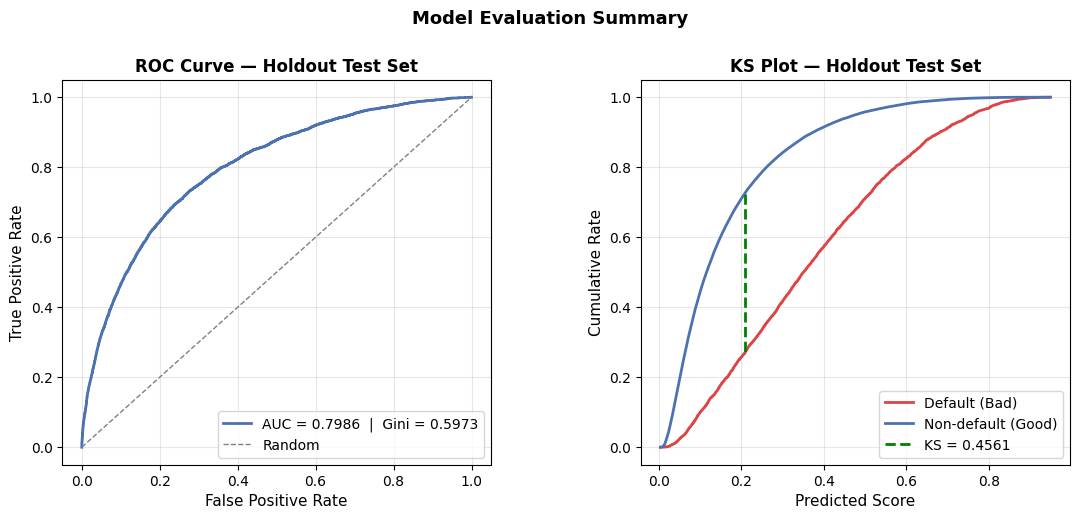

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve

# ── Compute metrics ───────────────────────────────────────────────────────────
oof_auc  = roc_auc_score(y_train, oof_preds)
test_auc = roc_auc_score(y_test,  test_preds)
gini     = 2 * test_auc - 1

# KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, test_preds)
ks_stat  = (tpr - fpr).max()
ks_thresh = thresholds[(tpr - fpr).argmax()]

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 40)
print(f"  OOF  AUC  : {oof_auc:.4f}")
print(f"  Test AUC  : {test_auc:.4f}")
print(f"  Gini      : {gini:.4f}")
print(f"  KS Stat   : {ks_stat:.4f}  (threshold = {ks_thresh:.3f})")
print("=" * 40)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# --- ROC Curve ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(fpr, tpr, color="#4C72B0", lw=2,
         label=f"AUC = {test_auc:.4f}  |  Gini = {gini:.4f}")
ax1.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random")
ax1.set_xlabel("False Positive Rate", fontsize=11)
ax1.set_ylabel("True Positive Rate", fontsize=11)
ax1.set_title("ROC Curve — Holdout Test Set", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# --- KS Plot ---
ax2 = fig.add_subplot(gs[1])

# Sort by score to build cumulative distributions
df_ks = pd.DataFrame({"score": test_preds, "target": y_test.values})
df_ks = df_ks.sort_values("score").reset_index(drop=True)
n_bad  = df_ks["target"].sum()
n_good = len(df_ks) - n_bad

df_ks["cum_bad"]  = df_ks["target"].cumsum() / n_bad
df_ks["cum_good"] = (1 - df_ks["target"]).cumsum() / n_good

ax2.plot(df_ks["score"], df_ks["cum_bad"],  color="#DD4444", lw=2, label="Default (Bad)")
ax2.plot(df_ks["score"], df_ks["cum_good"], color="#4C72B0", lw=2, label="Non-default (Good)")

# Mark KS gap
ks_idx = (df_ks["cum_bad"] - df_ks["cum_good"]).abs().idxmax()
ks_x   = df_ks.loc[ks_idx, "score"]
ks_y0  = df_ks.loc[ks_idx, "cum_good"]
ks_y1  = df_ks.loc[ks_idx, "cum_bad"]
ax2.vlines(ks_x, ks_y0, ks_y1, color="green", lw=2, linestyle="--",
           label=f"KS = {ks_stat:.4f}")

ax2.set_xlabel("Predicted Score", fontsize=11)
ax2.set_ylabel("Cumulative Rate", fontsize=11)
ax2.set_title("KS Plot — Holdout Test Set", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle("Model Evaluation Summary", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.7 — Save Artifacts

Saves all model artifacts to `OUTPUT_DIR`:
model pickle, OOF predictions, test predictions, feature names, and feature importance.


In [ ]:
# Model pickle
model_path = OUTPUT_DIR / "lgbm_ref_v1.pkl"
with open(model_path, "wb") as f:
    pickle.dump({
        "classifiers":   classifiers,
        "feature_names": feature_names,
        "meanenc_feats": meanenc_feats,
        "cat_feats":     cat_feats,
    }, f)
logger.info(f"Model saved → {model_path}")

# OOF predictions
pd.DataFrame({"oof_pred": oof_preds, "target": y_train.values}).to_csv(
    OUTPUT_DIR / "oof_predictions.csv", index=False)

# Test predictions
pd.DataFrame({"test_pred": test_preds, "target": y_test.values}).to_csv(
    OUTPUT_DIR / "test_predictions.csv", index=False)

# Feature names
with open(OUTPUT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

# Feature importance (averaged across folds)
importance_gain  = np.zeros(len(feature_names))
importance_split = np.zeros(len(feature_names))
for clf in classifiers:
    if clf.feature_importances_gain_ is not None:
        importance_gain  += clf.feature_importances_gain_  / len(classifiers)
        importance_split += clf.feature_importances_split_ / len(classifiers)

pd.DataFrame({
    "feature":          feature_names,
    "importance_gain":  importance_gain,
    "importance_split": importance_split,
}).sort_values("importance_gain", ascending=False).to_csv(
    OUTPUT_DIR / "feature_importance.csv", index=False)

logger.info("All artifacts saved.")

04:39:42 | INFO | Model saved → ..\models\lgbm_ref_v1.pkl
04:39:43 | INFO | All artifacts saved.
